# Netflix Data Analysis Using Python

## Project Overview

This project focuses on analyzing Netflix data using Python.
The analysis includes data loading, data cleaning, exploration,
visualization, and extracting meaningful insights from the dataset.

## Task 1: Netflix Data Cleaning & Preparation

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


### Step 1: Import the Dataset

In [53]:
df = pd.read_csv("Dataset.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [54]:
df.shape

(8790, 10)

In [55]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [57]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [58]:
df.describe(include="all")

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
count,8790,8790,8790,8790,8790,8790,8790.000000,8790,8790,8790
unique,8790,2,8787,4528,86,1713,NaN,14,220,513
top,s1,Movie,9-Feb,Not Given,United States,1/1/2020,NaN,TV-MA,1 Season,"Dramas, International Movies"
freq,1,6126,2,2588,3240,110,NaN,3205,1791,362
mean,NaN,NaN,NaN,NaN,NaN,NaN,2014.183163,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,8.825466,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN


### Step 2: Identify and Handle Missing Values

In [59]:
missing_values = df.isnull().sum()
missing_values

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [60]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

show_id         0.0
type            0.0
title           0.0
director        0.0
country         0.0
date_added      0.0
release_year    0.0
rating          0.0
duration        0.0
listed_in       0.0
dtype: float64

In [61]:
total_missing = df.isnull().sum().sum()

print("Total Missing Values:", total_missing)

Total Missing Values: 0


**Step 2 Result:** The dataset was checked for missing values. No missing values were found in the dataset, so no additional missing value treatment was required.

### Step 3: Remove Duplicate Records and Formatting Inconsistencies

In [62]:
duplicate_count = df.duplicated().sum()

print("Total Duplicate Records:", duplicate_count)

Total Duplicate Records: 0


In [63]:
df = df.drop_duplicates()

print("Duplicates removed successfully!")

Duplicates removed successfully!


In [64]:
text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

In [65]:
print("Remaining Duplicate Records:", df.duplicated().sum())

df.head()

Remaining Duplicate Records: 0


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


### Step 4: Standardize Country, Rating, and Type

In [66]:
df['country'] = df['country'].str.title()

In [67]:
df['rating'] = df['rating'].str.upper()

In [68]:
df['type'] = df['type'].str.strip().replace({
    'Tv Show': 'TV Show',
    'Movie': 'Movie'
})

In [69]:
df[['type', 'country', 'rating']].head()

,type,country,rating
0,Movie,United States,PG-13
1,TV Show,France,TV-MA
2,TV Show,United States,TV-MA
3,Movie,Brazil,TV-PG
4,Movie,United States,TV-MA


### Step 5: Export the Cleaned Dataset

In [70]:
df.to_csv("cleaned_netflix_data.csv", index=False)

In [71]:
import os

print(os.path.exists("cleaned_netflix_data.csv"))

True


In [97]:
cleaned_df = pd.read_csv("cleaned_netflix_data.csv")

cleaned_df.head(15)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
5,s9,TV Show,The Great British Baking Show,Andy Devonshire,United Kingdom,9/24/2021,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
6,s10,Movie,The Starling,Theodore Melfi,United States,9/24/2021,2021,PG-13,104 min,"Comedies, Dramas"
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,5/1/2021,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu..."
8,s13,Movie,Je Suis Karl,Christian Schwochow,Germany,9/23/2021,2021,TV-MA,127 min,"Dramas, International Movies"
9,s940,Movie,Motu Patlu in Wonderland,Suhas Kadav,India,5/1/2021,2013,TV-Y7,76 min,"Children & Family Movies, Music & Musicals"


**Step 5 Result:** The cleaned Netflix dataset was successfully exported as `cleaned_netflix_data.csv` and is ready for further analysis.

## Task 2: Content Type Analysis Dashboard

### Step 1: Load the Cleaned Dataset

In [73]:
df_cleaned = pd.read_csv("cleaned_netflix_data.csv")

df_cleaned.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


### Step 2: Calculate the Total Number of Movies and TV Shows

In [74]:
content_counts = df_cleaned['type'].value_counts()

content_counts

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

### Step 3: Create Visualizations for Content Distribution

### Bar Chart

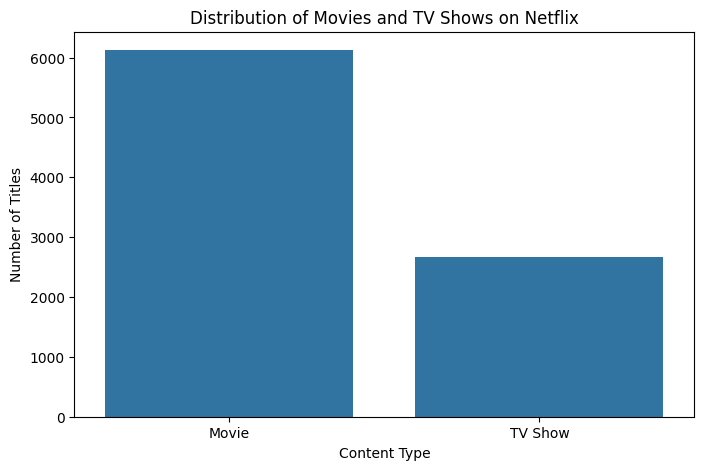

In [75]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_cleaned, x='type')

plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

### Pie Chart

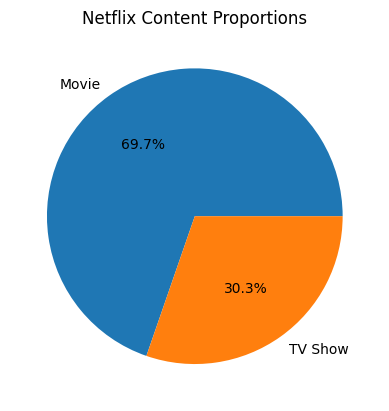

In [76]:
content_counts.plot(kind='pie',autopct='%1.1f%%',ylabel='',title='Netflix Content Proportions')
plt.show()

### Step 4: Compare Content Proportions

In [77]:
content_proportions = (df_cleaned['type'].value_counts(normalize=True) * 100)

content_proportions

type
Movie      69.692833
TV Show    30.307167
Name: proportion, dtype: float64

### Step 5: Summarize Key Findings

In [78]:
movie_count = (df_cleaned['type'] == 'Movie').sum()
tv_show_count = (df_cleaned['type'] == 'TV Show').sum()

print("Key Findings:")
print(f"Total Movies: {movie_count}")
print(f"Total TV Shows: {tv_show_count}")

Key Findings:
Total Movies: 6126
Total TV Shows: 2664


### Key Insights

- Netflix has a higher number of Movies compared to TV Shows.
- Movies represent the largest proportion of the available content.
- TV Shows represent a smaller but significant portion of Netflix's content library.

## Task 3: Country-Wise Netflix Content Analysis

### Step 1: Extract and Clean Country Information

In [79]:
country_data = df_cleaned.copy()

country_data['country'] = country_data['country'].str.split(',')

country_data = country_data.explode('country')

country_data['country'] = country_data['country'].str.strip()

country_data.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


### Step 2: Calculate Content Count by Country

In [80]:
country_counts = country_data['country'].value_counts()

country_counts.head(10)

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

### Step 3: Visualize Top 10 Countries by Content

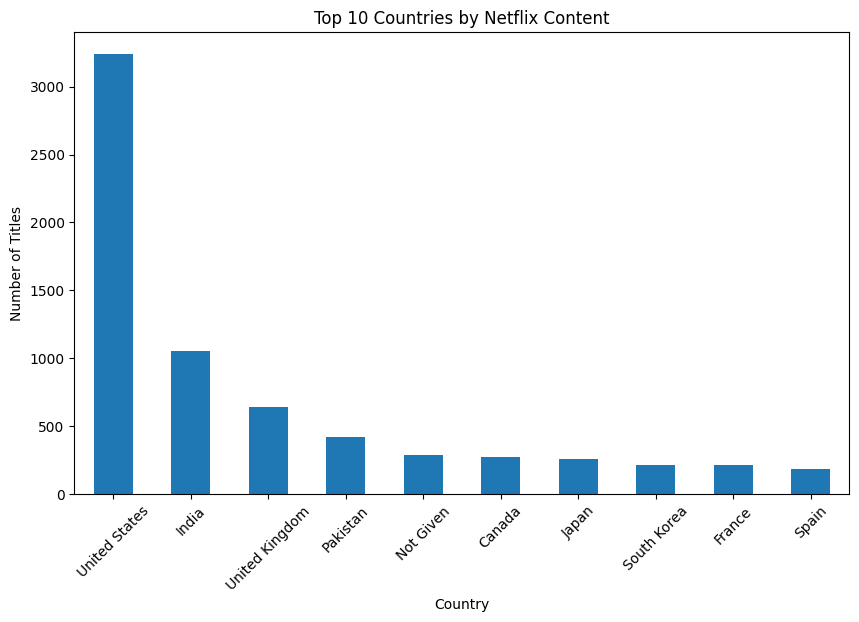

In [81]:
top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

### Step 4: Identify the Country with the Most Content

In [82]:
top_country = country_counts.idxmax()
top_country_count = country_counts.max()

print("Country with the Most Netflix Content:", top_country)
print("Number of Titles:", top_country_count)

Country with the Most Netflix Content: United States
Number of Titles: 3240


### Step 5: Summarize Key Findings

In [83]:
print("Key Findings:")
print(f"The country with the most Netflix content is {top_country}.")
print(f"It has {top_country_count} titles in the dataset.")
print("The top 10 countries contribute a significant portion of the Netflix content.")

Key Findings:
The country with the most Netflix content is United States.
It has 3240 titles in the dataset.
The top 10 countries contribute a significant portion of the Netflix content.


### Key Insights

- The country with the highest number of Netflix titles is identified through the country-wise analysis.
- A small number of countries contribute a large share of the available content.
- Country-wise analysis helps identify the major content-producing regions on Netflix.

## Task 4: Year-Wise Netflix Content Analysis

### Step 1: Analyze Content by Release Year

In [84]:
year_data = df_cleaned.copy()

year_data['release_year'] = pd.to_numeric(
    year_data['release_year'],
    errors='coerce'
)

year_counts = year_data['release_year'].value_counts().sort_index()

year_counts.tail(10)

release_year
2012     236
2013     286
2014     352
2015     555
2016     901
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64

### Step 2: Identify the Years with the Most Content

In [85]:
top_years = year_counts.sort_values(ascending=False).head(10)

top_years

release_year
2018    1146
2017    1030
2019    1030
2020     953
2016     901
2021     592
2015     555
2014     352
2013     286
2012     236
Name: count, dtype: int64

### Step 3: Visualize Content by Release Year

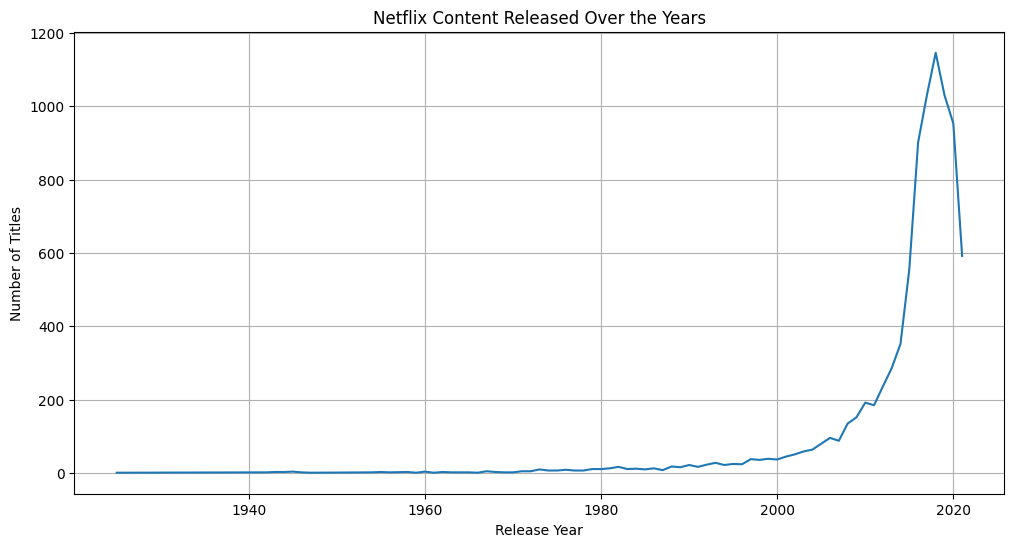

In [86]:
plt.figure(figsize=(12, 6))

year_counts.plot(kind='line')

plt.title("Netflix Content Released Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid()
plt.show()

### Step 4: Analyze the Peak Content Release Year

In [87]:
peak_year = year_counts.idxmax()
peak_count = year_counts.max()

print("Peak Content Release Year:", peak_year)
print("Number of Titles Released:", peak_count)

Peak Content Release Year: 2018
Number of Titles Released: 1146


### Step 5: Summarize Key Findings

In [88]:
print("Key Findings:")
print(f"The highest number of Netflix titles was released in {peak_year}.")
print(f"A total of {peak_count} titles were released in that year.")
print("The release-year analysis shows how Netflix content production changed over time.")

Key Findings:
The highest number of Netflix titles was released in 2018.
A total of 1146 titles were released in that year.
The release-year analysis shows how Netflix content production changed over time.


### Key Insights

- Netflix content increased significantly during recent years.
- The peak release year contains the highest number of titles in the dataset.
- Year-wise analysis helps understand the growth of Netflix's content library over time.

## Task 5: Content Rating and Genre Analysis

### Step 1: Analyze Netflix Content by Rating

In [89]:
rating_counts = df_cleaned['rating'].value_counts()

rating_counts

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [90]:
most_common_rating = rating_counts.idxmax()
most_common_rating_count = rating_counts.max()

print("Most Common Rating:", most_common_rating)
print("Number of Titles:", most_common_rating_count)

Most Common Rating: TV-MA
Number of Titles: 3205


### Step 2: Identify the Most Common Genres

In [91]:
genre_data = df_cleaned.copy()

genre_data['listed_in'] = genre_data['listed_in'].str.split(',')

genre_data = genre_data.explode('listed_in')

genre_data['listed_in'] = genre_data['listed_in'].str.strip()

genre_counts = genre_data['listed_in'].value_counts()

genre_counts.head(10)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

### Step 3: Compare Ratings Across Content Types

In [92]:
rating_type_comparison = pd.crosstab(
    df_cleaned['rating'],
    df_cleaned['type']
)

rating_type_comparison.head(10)

type,Movie,TV Show
rating,,
G,41,0
NC-17,3,0
NR,75,4
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,730
TV-G,126,94
TV-MA,2062,1143


### Step 4: Create Rating and Genre Visualizations

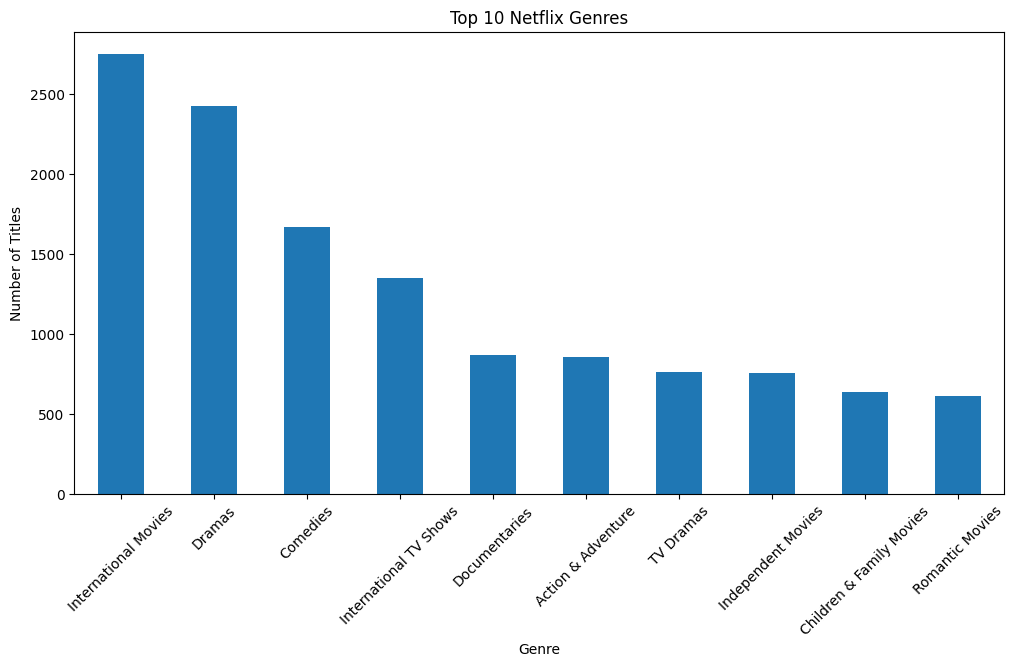

In [93]:
plt.figure(figsize=(12, 6))
genre_counts.head(10).plot(kind='bar')

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

### Step 5: Present Audience Insights
- Genre analysis helps identify the most common types of content available on Netflix.
- Rating categories provide insights into the different audience groups targeted by Netflix.
- Comparing ratings across Movies and TV Shows helps understand audience segmentation.

### Key Insights

- Netflix content is distributed across several audience rating categories.
- The most common rating represents a significant portion of the content library.
- Rating analysis helps understand the type of audience targeted by Netflix content.

## Task 6: Final Analysis and Conclusion

### Step 1: Generate Overall Dataset Summary

In [94]:
print("Netflix Dataset Summary")
print("-----------------------")
print("Total Titles:", len(df_cleaned))
print("Total Movies:", movie_count)
print("Total TV Shows:", tv_show_count)
print("Top Content Country:", top_country)
print("Peak Release Year:", peak_year)
print("Most Common Rating:", most_common_rating)

Netflix Dataset Summary
-----------------------
Total Titles: 8790
Total Movies: 6126
Total TV Shows: 2664
Top Content Country: United States
Peak Release Year: 2018
Most Common Rating: TV-MA


### Step 2: Final Key Findings

### Final Insights

- Movies make up the larger share of Netflix content compared with TV Shows.
- The country-wise analysis identifies the major contributors to Netflix content.
- Netflix content increased significantly during recent years.
- The dataset contains content across several audience rating categories.
- Year-wise, country-wise, content-type-wise, and rating-wise analysis provides useful insights into Netflix's content library.

### Step 3: Create a Business Insights Dashboard

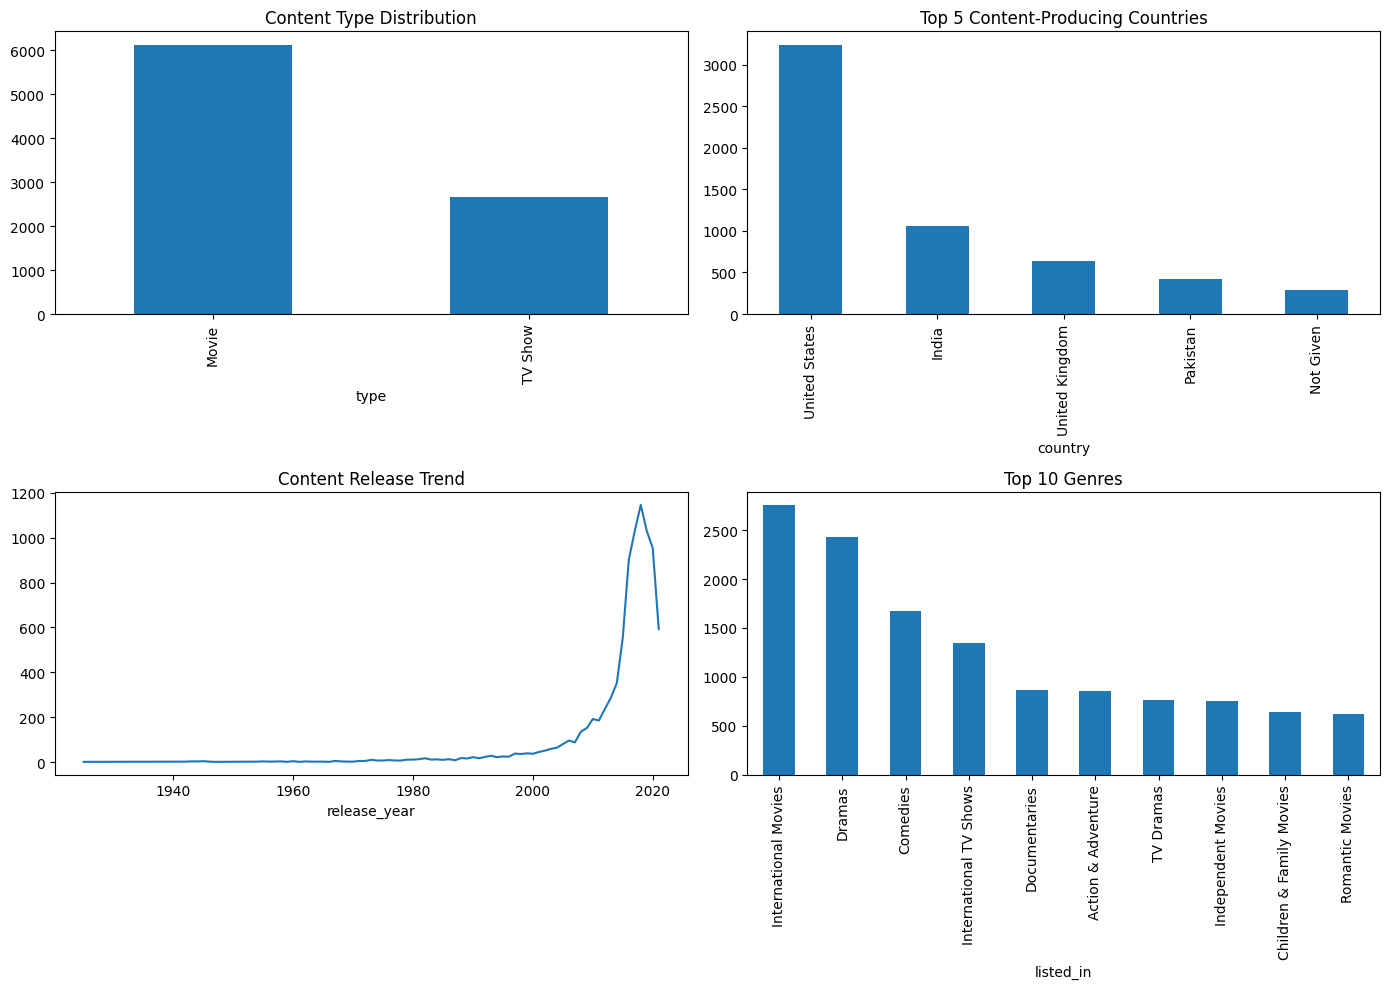

In [96]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

content_counts.plot(kind='bar',ax=axes[0, 0],title='Content Type Distribution')

top_countries.head(5).plot(kind='bar',ax=axes[0, 1],title='Top 5 Content-Producing Countries')

year_counts.plot(kind='line',ax=axes[1, 0],title='Content Release Trend')

genre_counts.head(10).plot(kind='bar',ax=axes[1, 1],title='Top 10 Genres')

plt.tight_layout()
plt.show()

### Step 4: Generate Actionable Business Insights

### Business Recommendations

- Netflix can continue investing in content categories that show strong representation in the dataset.
- The major content-producing countries can be important markets for content acquisition and production partnerships.
- Popular genres can help guide future content planning and audience engagement strategies.
- Audience ratings can support better content targeting for different viewer groups.
- Year-wise content trends can help identify periods of rapid content growth and changes in the content library.

### Step 5: Prepare the Final Analytical Report

### Final Analytical Report

This project performed an end-to-end analysis of Netflix content using Python. The dataset was cleaned and prepared before conducting content type, country-wise, year-wise, rating-wise, and genre-wise analysis.

The analysis revealed important patterns in Netflix's content library, including the distribution of Movies and TV Shows, major content-producing countries, changes in content releases over time, popular genres, and audience rating categories.

The visualizations and business insights generated in this project can support data-driven decision-making related to content planning, audience targeting, and content acquisition.